# Cleanlab Issues Analysis

We want to do here:

+ Conf in given label per class
+ Conf in sugg label per class
+ 

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Preprocessing

Model flags some samples as issues but suggest same label
This happens in 2020 ssample of the issues, representing 54.66847090663058% of the issues flagged
This issue have the same confidence in either labels with: 
	- Maximum conf = 0.988085923285189
	- Minimum conf = 0.4396744460089877

As seen below the correlation between scores in this samples is perfect.


Text(0, 0.5, 'conf in suggested')

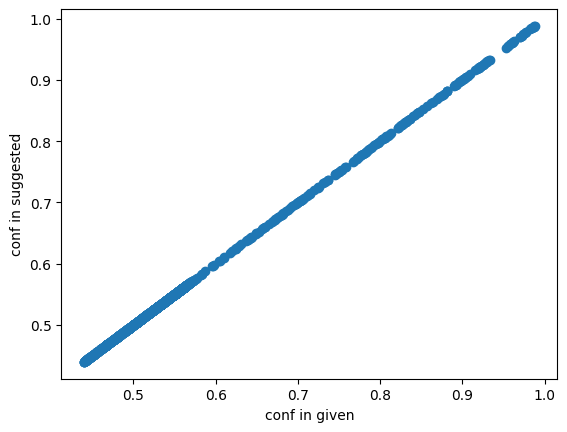

In [2]:
df = pd.read_csv("../../outputs/analysis/data_quality/label_issues.csv")
df
# Remove the columns where given==suggested
same = df["given_label"] == df["suggested_label"]
df_same = df[same]
print(f"Model flags some samples as issues but suggest same label")
print(f"This happens in {np.sum(same)} ssample of the issues, representing {np.mean(same) * 100}% of the issues flagged")
print("This issue have the same confidence in either labels with: ")
print(f"\t- Maximum conf = {np.max(df_same['confidence_in_given'])}")
print(f"\t- Minimum conf = {np.min(df_same['confidence_in_given'])}")

print("\nAs seen below the correlation between scores in this samples is perfect.")
plt.scatter(df_same["confidence_in_given"], df_same["confidence_in_suggested"])
plt.xlabel("conf in given")
plt.ylabel("conf in suggested")

Given this are probably just difficult samples lets remove them from the issues list. Hereafter we do not consider this as issues, but instead just complex examples. 

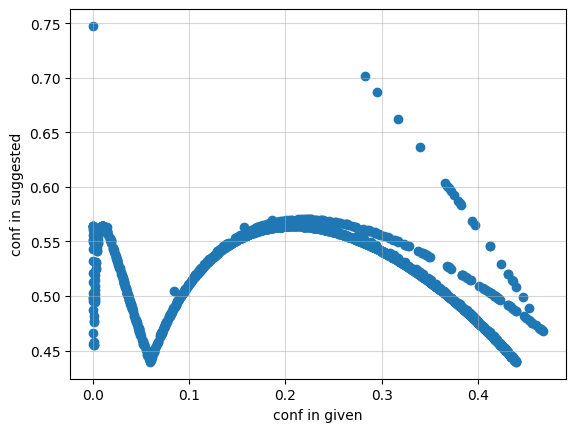

In [24]:
df_issues = df[~same]


plt.scatter(df_issues["confidence_in_given"], df_issues["confidence_in_suggested"])
plt.xlabel("conf in given")
plt.ylabel("conf in suggested")
plt.grid(True, alpha = 0.5)

In [36]:
df_issues

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested
0,175,24409454,10,5,8.031457e-12,0.564128
1,2189,24601200,5,9,1.932301e-08,0.562265
2,1241,24319685,4,8,2.427852e-08,0.556369
3,2021,24319683,5,8,3.493361e-06,0.455733
4,363,24601328,10,7,9.872978e-06,0.512644
...,...,...,...,...,...,...
1814,267,24727483,10,9,4.634575e-01,0.470652
1821,278,24719424,10,9,4.644137e-01,0.470014
1825,451,24316234,10,9,4.646442e-01,0.469860
1845,336,23894714,10,9,4.665105e-01,0.468610


## Exploratory Analysis

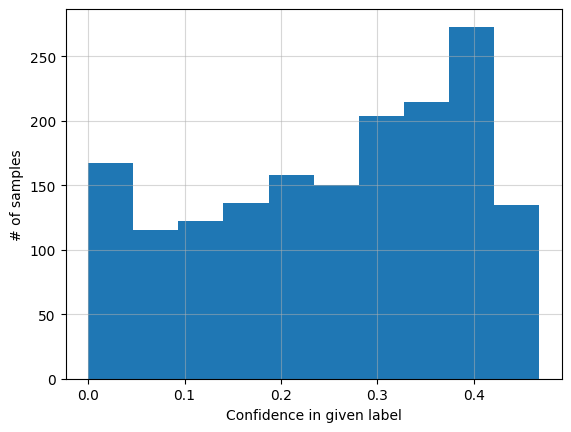

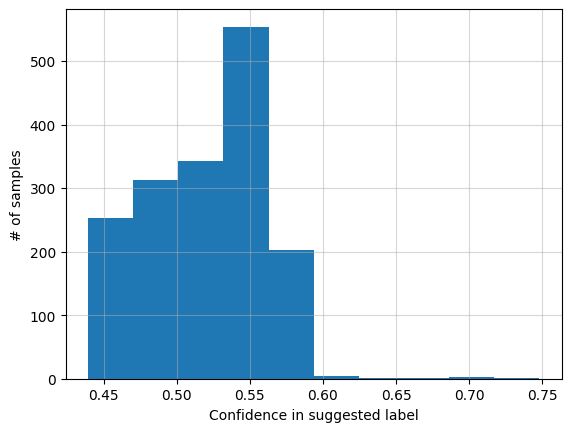

In [4]:
plt.hist(df_issues["confidence_in_given"])
plt.xlabel("Confidence in given label")
plt.ylabel("# of samples")
plt.grid(True, alpha = 0.5)
plt.show()

plt.hist(df_issues["confidence_in_suggested"])
plt.xlabel("Confidence in suggested label")
plt.ylabel("# of samples")
plt.grid(True, alpha = 0.5)
plt.show()

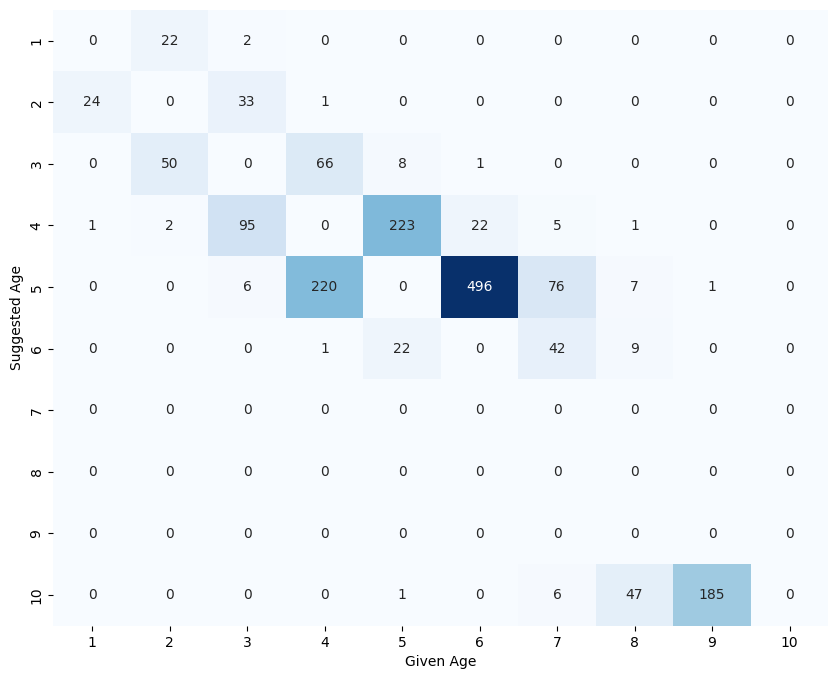

In [79]:

# Create confusion matrix with 1-indexed labels
cm = confusion_matrix(df_issues["given_label"] + 1, df_issues["suggested_label"] + 1)

# Create labels for display
n_classes = cm.shape[0]
labels = list(range(1, n_classes + 1))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap = "Blues", cbar = False)
plt.xlabel('Given Age')
plt.ylabel('Suggested Age')
plt.show()

## Confidence in Given per Class


In [5]:
df_issues

,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested
0,175,24409454,10,5,8.031457e-12,0.564128
1,2189,24601200,5,9,1.932301e-08,0.562265
2,1241,24319685,4,8,2.427852e-08,0.556369
3,2021,24319683,5,8,3.493361e-06,0.455733
4,363,24601328,10,7,9.872978e-06,0.512644
...,...,...,...,...,...,...
1814,267,24727483,10,9,4.634575e-01,0.470652
1821,278,24719424,10,9,4.644137e-01,0.470014
1825,451,24316234,10,9,4.646442e-01,0.469860
1845,336,23894714,10,9,4.665105e-01,0.468610


Given label statistics:
             count    median       std      mean  ci_lower  ci_upper
given_label                                                         
1               24  0.238374  0.149342  0.264018  0.200956  0.327079
2               58  0.379005  0.093759  0.346631  0.321979  0.371284
3              125  0.331438  0.118017  0.299864  0.278972  0.320757
4              349  0.297703  0.126365  0.268354  0.255050  0.281658
5              806  0.271373  0.130122  0.248683  0.239686  0.257679
6               74  0.301853  0.136118  0.265012  0.233476  0.296548
10             239  0.187612  0.141603  0.197765  0.179721  0.215809

Suggested label statistics:
                 count    median       std      mean  ci_lower  ci_upper
suggested_label                                                         
1                   25  0.583408  0.066912  0.580167  0.552547  0.607786
2                   74  0.509164  0.039700  0.512058  0.502861  0.521256
3                  136  0.511214  

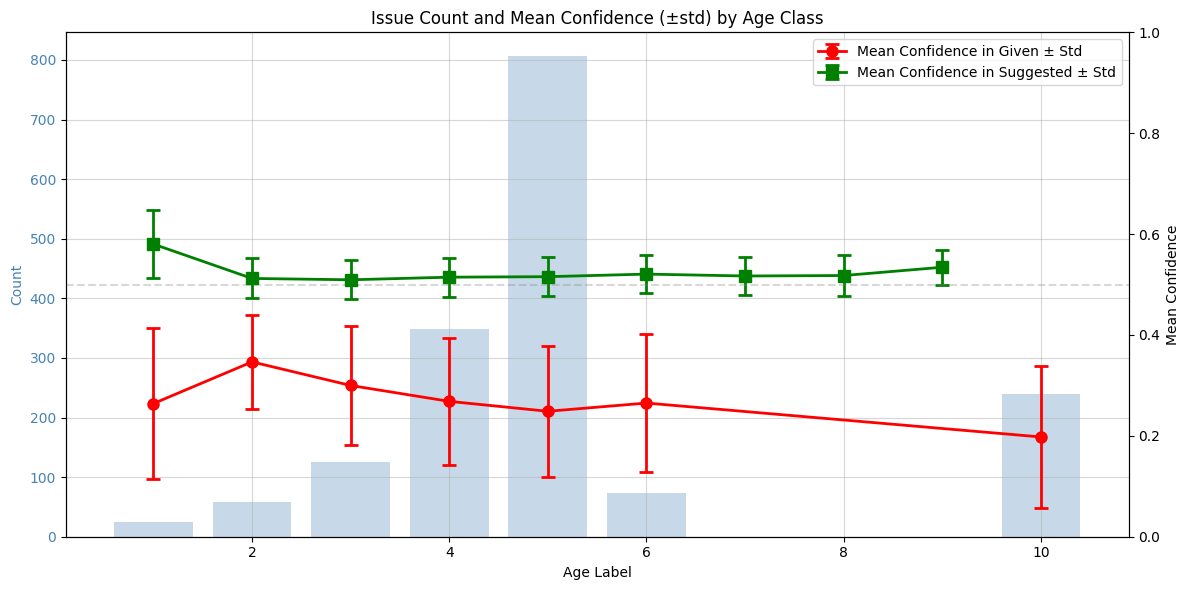

In [57]:
# Calculate statistics for given label (grouped by given_label)
result_given = df_issues.groupby('given_label')['confidence_in_given'].agg([
    ('count', 'count'),
    ('median', 'median'),
    ('std', 'std'),
    ('mean', 'mean')
])

# Calculate 95% CI for the mean of given label
result_given['ci_lower'] = result_given.apply(
    lambda row: row['mean'] - stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)
result_given['ci_upper'] = result_given.apply(
    lambda row: row['mean'] + stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)

# Calculate statistics for suggested label (grouped by suggested_label)
result_suggested = df_issues.groupby('suggested_label')['confidence_in_suggested'].agg([
    ('count', 'count'),
    ('median', 'median'),
    ('std', 'std'),
    ('mean', 'mean')
])

# Calculate 95% CI for the mean of suggested label
result_suggested['ci_lower'] = result_suggested.apply(
    lambda row: row['mean'] - stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)
result_suggested['ci_upper'] = result_suggested.apply(
    lambda row: row['mean'] + stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)

print("Given label statistics:")
print(result_given)
print("\nSuggested label statistics:")
print(result_suggested)

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.grid(True, alpha=0.5)

# Bar plot for counts (using given label counts)
ax1.bar(result_given.index, result_given['count'], alpha=0.3, color='steelblue', label='Count')
ax1.set_xlabel('Age Label')
ax1.set_ylabel('Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line plots for mean confidence with std as error bars
ax2 = ax1.twinx()

# Given label confidence (red)
ax2.errorbar(result_given.index, result_given['mean'], 
             yerr=result_given["std"], 
             color='red', marker='o', linewidth=2, markersize=8, 
             capsize=5, capthick=2, label='Mean Confidence in Given ± Std')

# Suggested label confidence (green)
ax2.errorbar(result_suggested.index, result_suggested['mean'], 
             yerr=result_suggested['std'], 
             color='green', marker='s', linewidth=2, markersize=8, 
             capsize=5, capthick=2, label='Mean Confidence in Suggested ± Std')

ax2.set_ylabel('Mean Confidence', color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim([0, 1])
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)

# Add legend for the confidence lines
ax2.legend(loc='upper right')

plt.title('Issue Count and Mean Confidence (±std) by Age Class')
fig.tight_layout()

plt.show()

In [7]:

# First, let's check what we're working with
print("Result shape:", result.shape)
print("Result columns:", result.columns)
print("\nStd values:")
print(result['std'])
print("Std shape:", result['std'].shape)

Result shape: (7, 3)
Result columns: Index(['count', 'median', 'std'], dtype='object')

Std values:
given_label
1     0.149342
2     0.093759
3     0.118017
4     0.126365
5     0.130122
6     0.136118
10    0.141603
Name: std, dtype: float64
Std shape: (7,)


### Misclassification Pattern Analysis

# Non issues Analysis

             count    median       std      mean  ci_lower  ci_upper
given_label                                                         
1               86  0.748809  0.119444  0.735354  0.709746  0.760963
2              165  0.547100  0.031572  0.538721  0.533868  0.543574
3              223  0.536754  0.036227  0.526025  0.521245  0.530806
4              419  0.531710  0.035357  0.523225  0.519829  0.526620
5              889  0.538218  0.036854  0.526385  0.523959  0.528811
6               65  0.536201  0.037097  0.522256  0.513064  0.531449
10             173  0.757292  0.155465  0.753271  0.729941  0.776602


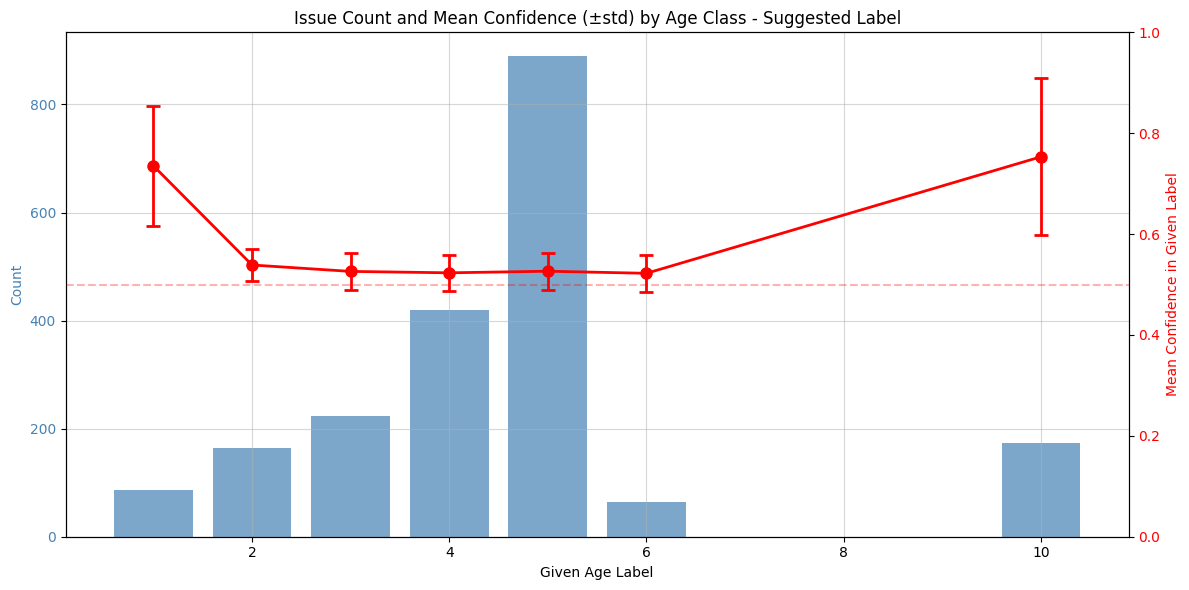

In [58]:
df_non_issues = df[same]

df_non_issues

# If your categorical variable is numeric (like age classes 0-16)
result = df_non_issues.groupby('given_label')['confidence_in_given'].agg([
    ('count', 'count'),
    ('median', 'median'),
    ('std', 'std'),
    ('mean', 'mean')
])

# Calculate 95% CI for the mean
result['ci_lower'] = result.apply(
    lambda row: row['mean'] - stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)
result['ci_upper'] = result.apply(
    lambda row: row['mean'] + stats.t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']),
    axis=1
)

print(result)


fig, ax1 = plt.subplots(figsize=(12, 6))
plt.grid(True, alpha = 0.5)

# Bar plot for counts
ax1.bar(result.index, result['count'], alpha=0.7, color='steelblue', label='Count')
ax1.set_xlabel('Given Age Label')
ax1.set_ylabel('Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line plot for mean confidence with std as error bars


ax2 = ax1.twinx()
ax2.errorbar(result.index, result['mean'], yerr=result["std"], 
             color='red', marker='o', linewidth=2, markersize=8, 
             capsize=5, capthick=2, label='Mean ± Std')
ax2.set_ylabel('Mean Confidence in Given Label', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 1])
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

plt.title('Issue Count and Mean Confidence (±std) by Age Class - Suggested Label')
fig.tight_layout()

plt.show()




# Other Stuff

In [8]:
# Load data 
data = np.load("../../outputs/embeddings/clip-vit-l-14-336_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

# Selecting metadata to include in feature vector
columns = ["length","quarter_2","quarter_3","quarter_4"]
metadata_csv = "../../cod_otolith_age_final_with_quarters.csv"

features = augment_embeddings(      # Augments the feature vectors with the metadata quarters and fish length
                features, measurements_ids, metadata_csv, columns
            )


rs = 77 # Random State 


# Train/Test split
## Will use CV therefore no validation split

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, stratify=labels, random_state = rs)

print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")


alphas = np.logspace(1.5, 3, 50)
print(f"Alphas range: {round(alphas.min(), 2)} to {alphas.max()}")

NameError: name 'augment_embeddings' is not defined

## Cleanlab

In [ ]:
df = pd.DataFrame({"age": y_train})

df

,age
0,6
1,8
2,6
3,4
4,4
...,...
7336,6
7337,6
7338,6
7339,7


In [ ]:



lab = Datalab(data = df, label_name="age")
lab.find_issues(features=X_train)
lab.report()  # summarize issues in dataset, how severe they are in each data point, ...

AssertionError: 

In [ ]:
# Check what type y_train is
print(f"Type of y_train: {type(y_train)}")
print(f"First few values: {y_train[:5]}")

# Try different conversions
if hasattr(y_train, 'values'):  # pandas Series
    y_list = y_train.values.tolist()
elif hasattr(y_train, 'numpy'):  # torch tensor
    y_list = y_train.numpy().tolist()
else:  # already numpy or list
    y_list = list(y_train)

# Now this should work
lab = Datalab(data={"age": y_list}, label_name="age")
lab.find_issues(features=X_train)
lab.report()

Type of y_train: <class 'numpy.ndarray'>
First few values: [6 8 6 4 4]


AssertionError: 

In [ ]:
# Get the actual full error
import traceback

try:
    df = pd.DataFrame({"age": y_train})
    lab = Datalab(data=df, label_name="age")
except Exception as e:
    print("Full error traceback:")
    traceback.print_exc()
    print(f"\nError type: {type(e)}")
    print(f"Error message: {str(e)}")

# Also check what's actually in your data
print(f"\ny_train info:")
print(f"  Type: {type(y_train)}")
print(f"  Shape: {y_train.shape}")
print(f"  Dtype: {y_train.dtype}")
print(f"  First 10 values: {y_train[:10]}")
print(f"  Unique values: {np.unique(y_train)}")

# Check the DataFrame
print(f"\nDataFrame info:")
df = pd.DataFrame({"age": y_train})
print(df.info())
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataFrame['age'] type: {type(df['age'])}")
print(f"DataFrame['age'] dtype: {df['age'].dtype}")

Full error traceback:

Error type: <class 'AssertionError'>
Error message: 

y_train info:
  Type: <class 'numpy.ndarray'>
  Shape: (7341,)
  Dtype: int64
  First 10 values: [ 6  8  6  4  4  8  8  6  8 10]
  Unique values: [ 1  2  3  4  5  6  7  8  9 10]

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7341 entries, 0 to 7340
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     7341 non-null   int64
dtypes: int64(1)
memory usage: 57.5 KB
None

First few rows:
   age
0    6
1    8
2    6
3    4
4    4

DataFrame['age'] type: <class 'pandas.core.series.Series'>
DataFrame['age'] dtype: int64


Traceback (most recent call last):
  File "/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_3797/3668690916.py", line 6, in <module>
    lab = Datalab(data=df, label_name="age")
  File "/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/cleanlab/datalab/datalab.py", line 125, in __init__
    self._data = Data(data, self.task, label_name)
  File "/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/cleanlab/datalab/internal/data.py", line 160, in __init__
    self.labels = label_class(data=self._data, label_name=label_name, map_to_int=map_to_int)
  File "/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/cleanlab/datalab/internal/data.py", line 340, in __init__
    super().__init__(data=data, label_name=label_name, map_to_int=map_to_int)
  File "/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/cleanlab/datalab/internal/data.py", line 273, in __init__
    self._validate_labels()
  File "/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-

In [ ]:
# Workaround: Convert DataFrame column to numpy array manually
df = pd.DataFrame({"age": y_train})

# Monkey-patch the DataFrame to return numpy arrays
df_dict = {"age": df["age"].values}  # .values converts Series to numpy array

lab = Datalab(data=df_dict, label_name="age")
lab.find_issues(features=X_train)
lab.report()

AssertionError: 